# **Question 3: Multi-Class Segmentation for Animal Parts**

In this question, you should finetune a **pretrained U-Net** model for **multi-class segmentation** of animal parts. Your segmentation model will classify each pixel into **one of 5 classes** (Tail, Body, Legs, Head, Background).

Complete the code cells below.

---

In [ ]:
# # Please uncomment this out when you are running this lab on google colab!
# import os

# # Set KaggleHub cache to a directory inside /content/
# os.environ["KAGGLEHUB_CACHE"] = "/content/data"

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohammad2012191/segmentation")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/segmentation


## **TASK 1: Dataset Class**
- Build a custom dataset class to load images and masks.
- Use Dataloaders to prepare your data.
- Display some images and their corresponding masks.



In [2]:
def remap_mask(mask):
    # Remaps a mask's pixel values to a consecutive range starting at 0
    mask = mask.long()
    unique_values = torch.unique(mask)
    remapped_mask = torch.zeros_like(mask)
    
    for new_val, old_val in enumerate(sorted(unique_values.tolist())):
        remapped_mask[mask == old_val] = new_val
        
    return remapped_mask

In [3]:
import os
import pandas as pd
from PIL import Image
import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset
import numpy as np
# Custom Dataset Class
import os
import glob
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as transforms

class SegDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None, target_transform=None):
        self.image_paths = glob.glob(os.path.join(image_dir, "*.jpg"))  # Get all image paths
        self.mask_paths = glob.glob(os.path.join(mask_dir, "*.png"))  # Get all mask paths

        self.image_paths.sort()  
        self.mask_paths.sort()

        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # 🔹 Load the image and mask
        image = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx]).convert("L")

        # 🔹 Apply transformations for image
        if self.transform:
            image = self.transform(image)

        # 🔹 Apply transformations for mask
        if self.target_transform:
            mask = self.target_transform(mask)

        mask = remap_mask(mask)

        return image, mask  # Return image-mask pair

In [4]:
from torch.utils.data import DataLoader
from torch import nn

# Define transforms for images and masks
image_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((256, 256)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Standard ImageNet normalization
])

mask_transforms = transforms.Compose([
    transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.NEAREST),  # Keep segmentation masks intact
    transforms.PILToTensor(),
])

In [5]:
train_image_dir = os.path.join(path, "train", "images")
train_mask_dir = os.path.join(path, "train", "masks")

test_image_dir = os.path.join(path, "val", "images")
test_mask_dir = os.path.join(path, "val", "masks")

In [6]:
train_dataset = SegDataset(train_image_dir, train_mask_dir, transform=image_transforms, target_transform=mask_transforms)
test_dataset = SegDataset(test_image_dir, test_mask_dir, transform=image_transforms, target_transform=mask_transforms)


# Create Train & Test DataLoaders
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=2)

# Check dataset sizes
print(f"Training Samples: {len(train_dataset)}, Testing Samples: {len(test_dataset)}")


Training Samples: 1737, Testing Samples: 435


### Let's display some images

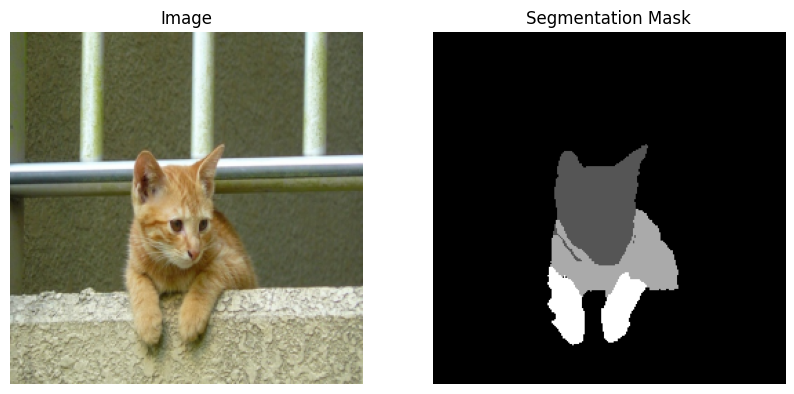

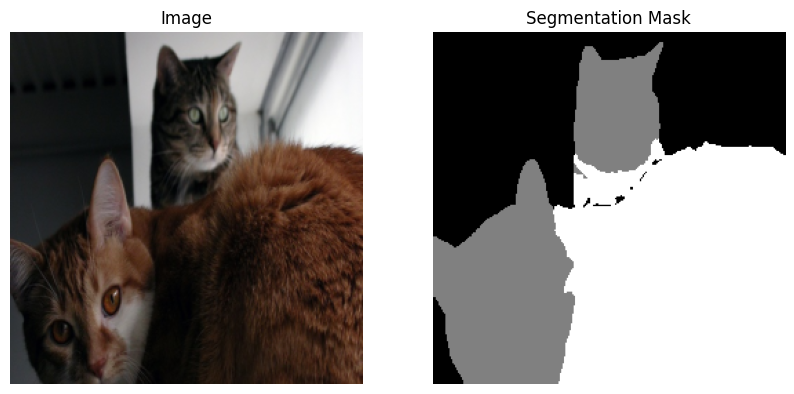

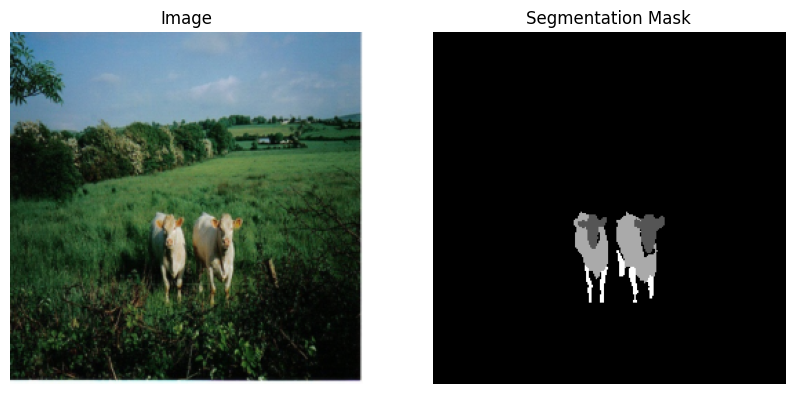

In [7]:
import matplotlib.pyplot as plt

# Function to denormalize images (We cannot show normalized images. We have to reverse normalizaion first.)
def denormalize(img):
    mean = np.array([0.485, 0.456, 0.406])  # ImageNet mean
    std = np.array([0.229, 0.224, 0.225])  # ImageNet std
    img = img.numpy().transpose(1, 2, 0)  # Convert to HWC
    img = img * std + mean  # Reverse normalization
    img = np.clip(img, 0, 1)  # Clip values to [0,1]
    return img

# Display some images with their masks
for i in range(3):
    img, mask = train_dataset[i]
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(denormalize(img))  
    axes[0].set_title("Image")
    axes[0].axis("off")
    axes[1].imshow(mask.permute(1, 2, 0), cmap="gray")
    axes[1].set_title("Segmentation Mask")
    axes[1].axis("off")
    plt.show()


## **TASK 2: Model Class**
- **Use a pretrained U-Net** (from `segmentation_models_pytorch`) with "resnet18" as an encoder.

In [8]:
!pip install -q segmentation_models_pytorch

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.3/121.3 kB 7.5 MB/s eta 0:00:00


In [9]:
import segmentation_models_pytorch as smp

# Define U-Net Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = smp.Unet(
    encoder_name="efficientnet-b0",  # Pretrained encoder (backbone)
    encoder_weights="imagenet",  # Use ImageNet weights
    in_channels=3,  # RGB images
    classes=5,  
).to(device)

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b0-355c32eb.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b0-355c32eb.pth
100%|██████████| 20.4M/20.4M [00:00<00:00, 316MB/s]


## **TASK 3: Training and Validation Loops**
- Define the training and validation loops.

In [10]:
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm

# 🔹 Training Loop
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for images, masks in tqdm(dataloader):
        images, masks = images.to(device), masks.to(device).squeeze(dim=1).to(torch.long)
        
        outputs = model(images)  
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

# 🔹 Validation Loop
def validate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for images, masks in dataloader:
            images, masks = images.to(device), masks.to(device).squeeze(dim=1).to(torch.long)

            outputs = model(images)  
            loss = criterion(outputs, masks)
            total_loss += loss.item()

    return total_loss / len(dataloader)

## **TASK 4: Running Training**
- Define the loss and the optimizer.
- Train the model for 10 epochs.
- Print the training and validation losses.
- Plot loss curve.

In [11]:
import torch
from torch import nn
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001)

num_epochs = 10  # Define number of epochs
train_losses = []
val_losses = []

# Training Loop
for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = validate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")


100%|██████████| 435/435 [00:30<00:00, 14.39it/s]


Epoch 1/10: Train Loss = 0.7837, Val Loss = 0.4200


100%|██████████| 435/435 [00:27<00:00, 15.72it/s]


Epoch 2/10: Train Loss = 0.4280, Val Loss = 0.3465


100%|██████████| 435/435 [00:28<00:00, 15.50it/s]


...

Epoch 8/10: Train Loss = 0.2101, Val Loss = 0.2611


100%|██████████| 435/435 [00:27<00:00, 15.63it/s]


Epoch 9/10: Train Loss = 0.1941, Val Loss = 0.2660


100%|██████████| 435/435 [00:28<00:00, 15.46it/s]


Epoch 10/10: Train Loss = 0.1831, Val Loss = 0.2610


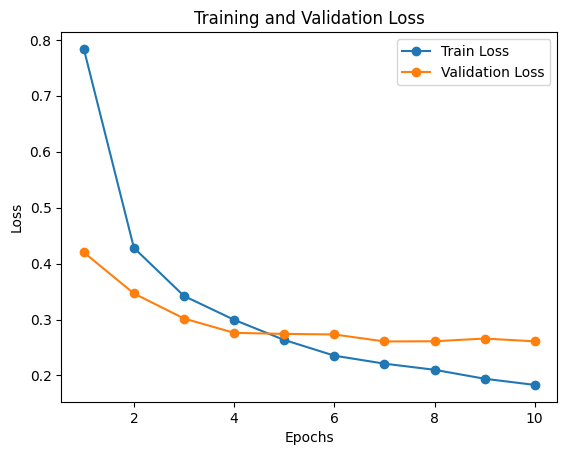

In [12]:
import matplotlib.pyplot as plt

plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, num_epochs+1), val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

## **TASK 5: Visualizing Predictions**
- Visualize your model's predictions against the ground truth for several images.

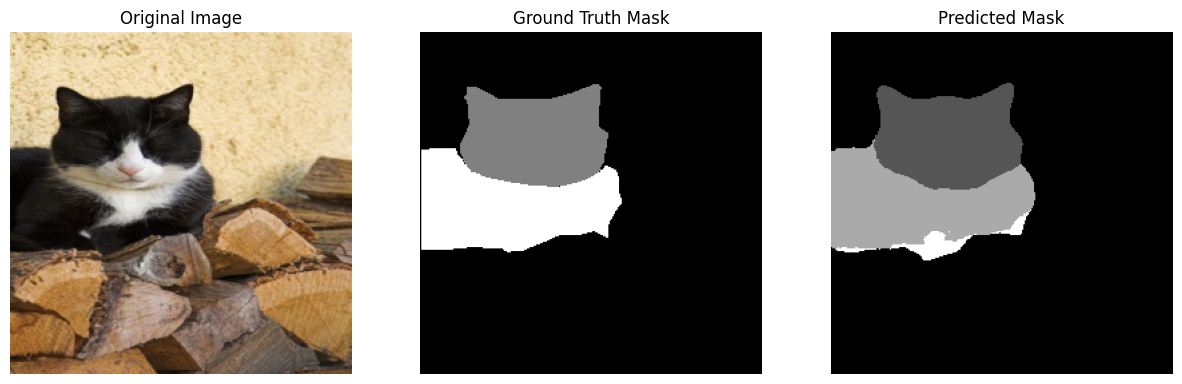

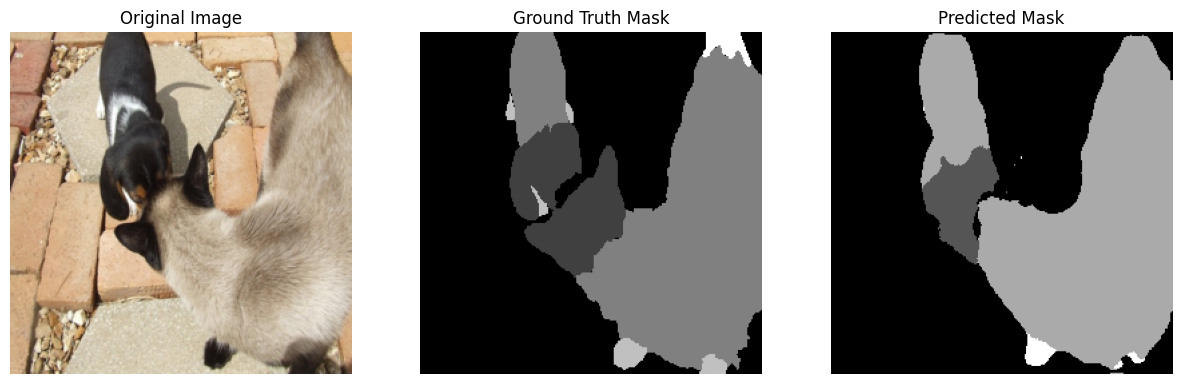

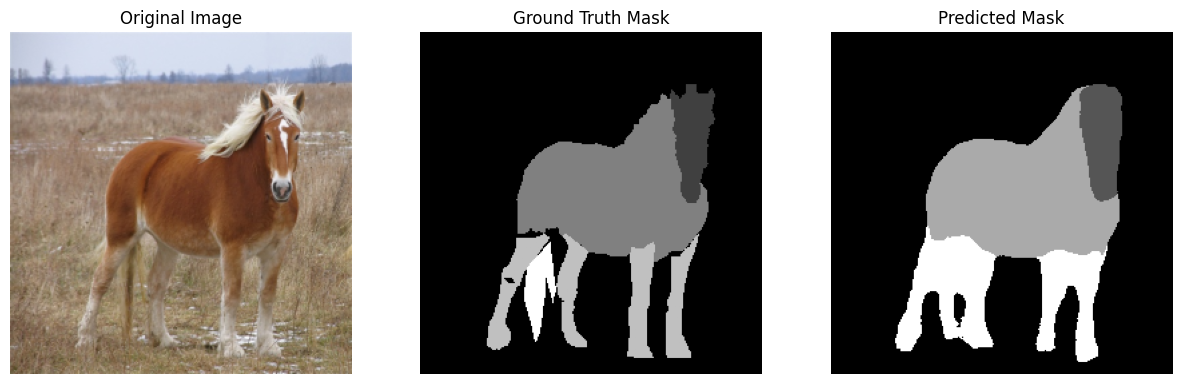

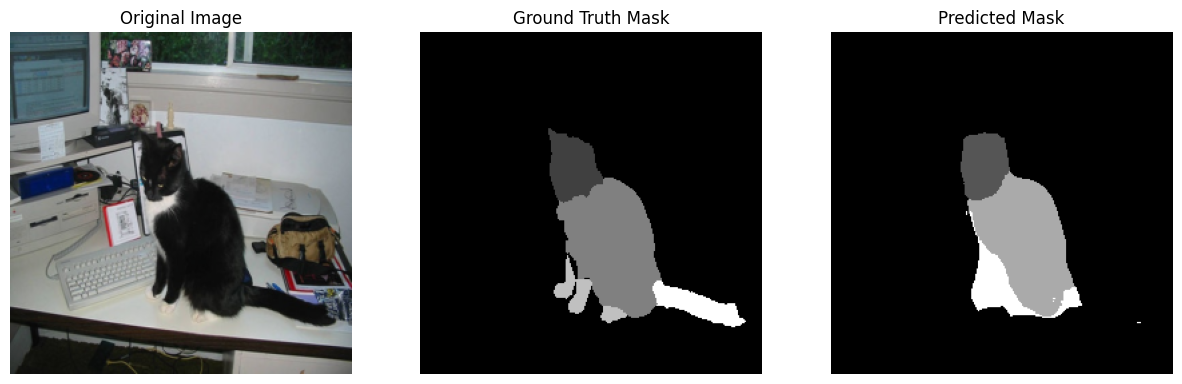

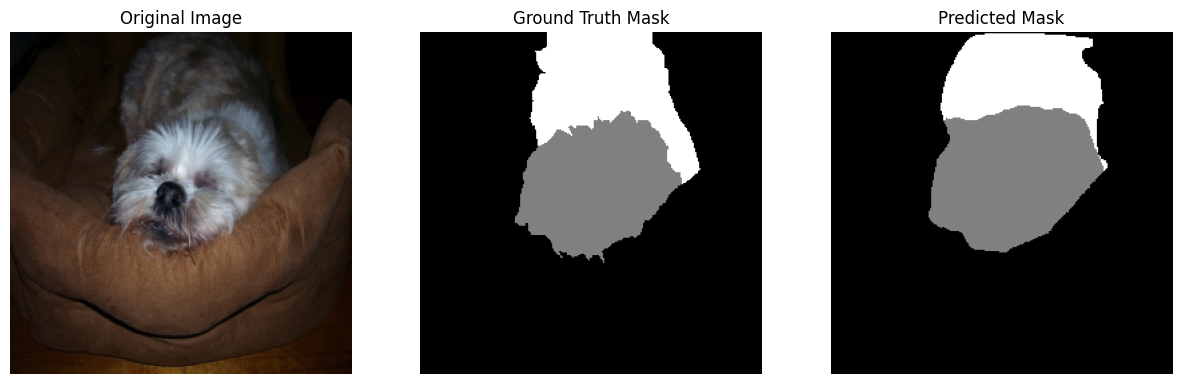

In [13]:
import random
import matplotlib.pyplot as plt
import numpy as np

# Function to denormalize images
def denormalize(img):
    mean = np.array([0.485, 0.456, 0.406])  # ImageNet mean
    std = np.array([0.229, 0.224, 0.225])  # ImageNet std
    img = img.numpy().transpose(1, 2, 0)  # Convert to HWC
    img = img * std + mean  # Reverse normalization
    img = np.clip(img, 0, 1)  # Clip values to [0,1]
    return img

# Set model to evaluation mode
model.eval()

# Get some test samples
test_samples = random.sample(range(len(test_dataset)), 5)

for idx in test_samples:
    img, mask = test_dataset[idx]

    with torch.no_grad():
            pred = model(img.unsqueeze(0).to(device))
            pred_mask = torch.argmax(torch.softmax(pred,dim=1), dim=1).cpu().squeeze()


    # Display images
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Original Image (Denormalized)
    axes[0].imshow(denormalize(img))
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    # Ground Truth Mask
    axes[1].imshow(mask.squeeze(), cmap="gray")
    axes[1].set_title("Ground Truth Mask")
    axes[1].axis("off")

    # Predicted Mask
    axes[2].imshow(pred_mask, cmap="gray")
    axes[2].set_title("Predicted Mask")
    axes[2].axis("off")

    plt.show()


# BONUS Task: Using Dice Loss & Dice Coefficient

**Dice loss** and **Dice coefficient** are widely used metrics for evaluating segmentation models. We typically use **Dice loss** during training because it is **differentiable**, and then calculate the **Dice coefficient** as a metric to measure performance—similar to how we use cross-entropy loss for training and accuracy for evaluation.


## **Your Bonus Tasks:**
- **Retrain** your previously built segmentation model using the **Dice loss** provided below.
- Modify the validation function to **evaluate** your retrained model using the **Dice coefficient** metric provided below.

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Dice Loss for multiclass segmentation (Lower is better)
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-5):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, inputs, targets):
        inputs = F.softmax(inputs, dim=1)
        targets = F.one_hot(targets, num_classes=inputs.shape[1]).permute(0, 3, 1, 2).float()
        
        intersection = (inputs * targets).sum(dim=(2, 3))
        total = inputs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
        
        dice_score = (2 * intersection + self.smooth) / (total + self.smooth)
        dice_loss = 1 - dice_score.mean()
        
        return dice_loss

# Dice Coefficient Metric (Higher is better)
def dice_coefficient(inputs, targets, smooth=1e-5):
    inputs = F.softmax(inputs, dim=1)
    targets = targets.squeeze(1)  
    targets = F.one_hot(targets, num_classes=inputs.shape[1]).permute(0, 3, 1, 2).float()
    
    intersection = (inputs * targets).sum(dim=(2, 3))
    total = inputs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
    
    dice_score = (2 * intersection + smooth) / (total + smooth)
    
    return dice_score.mean().item()


In [16]:
from tqdm import tqdm

# Validation loop
def validate(model, dataloader, device):
    model.eval()
    dice_score_total = 0

    with torch.no_grad():
        for images, masks in dataloader:
            images, masks = images.to(device), masks.to(device)

            outputs = model(images)
            dice_score = dice_coefficient(outputs, masks)
            dice_score_total += dice_score

    avg_dice_score = dice_score_total / len(dataloader)
    return avg_dice_score


In [23]:
model = smp.Unet(
    encoder_name="efficientnet-b0",  # Pretrained encoder (backbone)
    encoder_weights="imagenet",  # Use ImageNet weights
    in_channels=3,  # RGB images
    classes=5,  
).to(device)

In [24]:
criterion = DiceLoss()

optimizer = optim.AdamW(model.parameters(), lr=1e-4)
num_epochs = 10

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_dice = validate(model, test_loader, device)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f}, Val Dice Coefficient: {val_dice:.4f}")

100%|██████████| 435/435 [00:28<00:00, 15.38it/s]


Epoch [1/10] - Train Loss: 0.6756, Val Dice Coefficient: 0.4618


100%|██████████| 435/435 [00:28<00:00, 15.42it/s]


Epoch [2/10] - Train Loss: 0.5192, Val Dice Coefficient: 0.5369


100%|██████████| 435/435 [00:27<00:00, 15.62it/s]


...

Epoch [8/10] - Train Loss: 0.3906, Val Dice Coefficient: 0.5864


100%|██████████| 435/435 [00:28<00:00, 15.34it/s]


Epoch [9/10] - Train Loss: 0.3820, Val Dice Coefficient: 0.5845


100%|██████████| 435/435 [00:28<00:00, 15.21it/s]


Epoch [10/10] - Train Loss: 0.3733, Val Dice Coefficient: 0.5878
